In [2]:
import pandas as pd
import re
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter
from scipy.spatial.transform import rotation
from sklearn.externals.array_api_compat import size

from sklearn.cluster import DBSCAN
from sklearn import metrics
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import adjusted_rand_score

In [4]:
main_data = pd.read_csv('data/Medicare_Physician_Other_Practitioners_by_Provider_and_Service_2024.csv')
main_data
states = [
    "MD", "IL", "OH", "CO", "PA", "OK", "CA", "FL", "TX", "KY", "SC", "NV", "MO", "NY", "NJ", "VA", "LA", "TN", "MA", "OR","MI", "WA", "ME", "MN", "CT", "GA", "NC", "MS", "IA", "ND","ID", "NE", "AZ", "AL", "PR", "HI", "RI", "DC", "IN", "NM","AR", "WV", "VT", "NH", "AE", "KS", "DE", "WI", "MT", "WY","SD", "UT", "AK", "GU", "ZZ", "VI", "MP", "AP", "XX", "AA","FM", "AS"
]

C:\Users\tjwat\AppData\Local\Temp\ipykernel_33608\1548464839.py:1: DtypeWarning: Columns (10: Rndrng_Prvdr_State_FIPS, 11: Rndrng_Prvdr_Zip5) have mixed types. Specify dtype option on import or set low_memory=False.
  main_data = pd.read_csv('data/Medicare_Physician_Other_Practitioners_by_Provider_and_Service_2024.csv')


Text(0, 0.5, 'Amount of Providers')

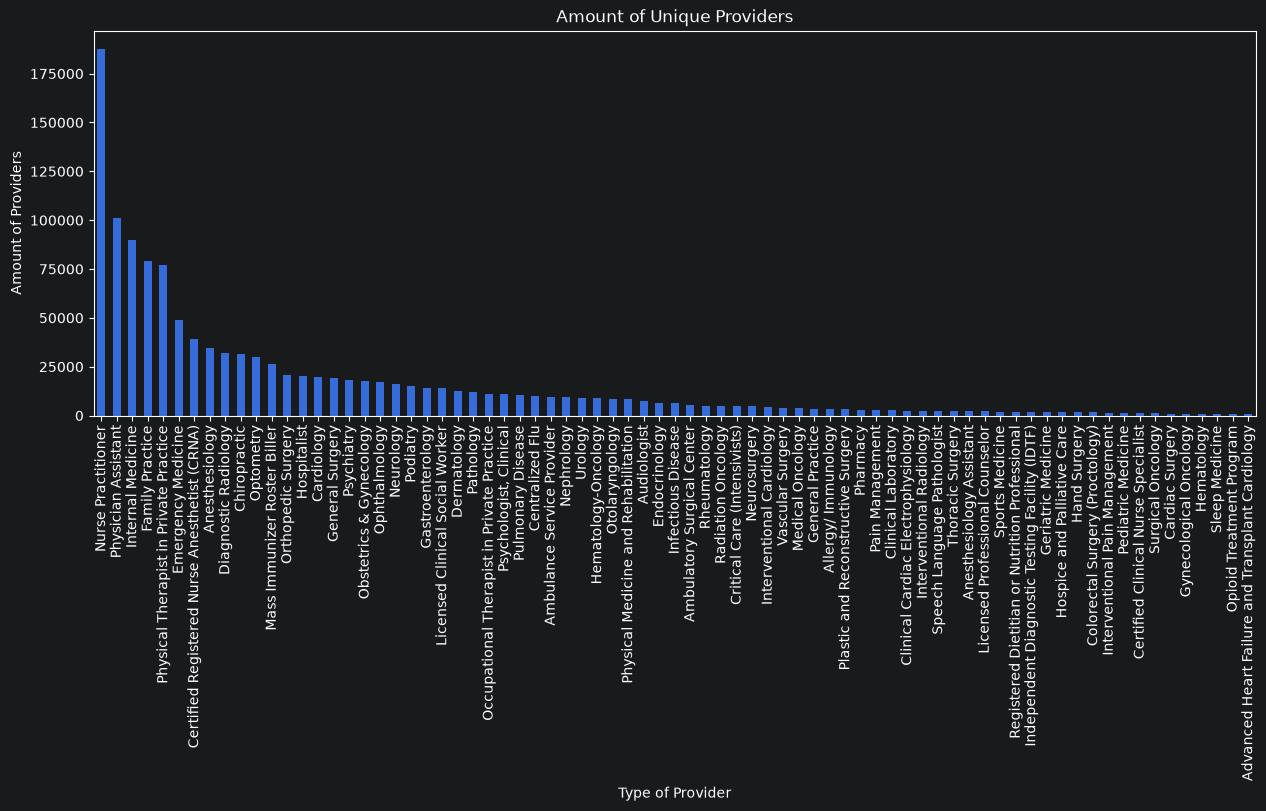

In [19]:
data_NPI = main_data.groupby('Rndrng_Prvdr_Type')['Rndrng_NPI'].nunique().sort_values(ascending=False).head(75)
fig, ax = plt.subplots(figsize=(15,5))
data_NPI.plot(kind='bar')
plt.title('Amount of Unique Providers')
plt.xlabel('Type of Provider')
plt.ylabel('Amount of Providers')

In [36]:


for state in states:
    state_data = main_data[main_data['Rndrng_Prvdr_State_Abrvtn']==state]
    data_NPI = state_data.groupby('Rndrng_Prvdr_Type')['Rndrng_NPI'].nunique().sort_values(ascending=False).head(75)
    fig, ax = plt.subplots(figsize=(15,5))
    data_NPI.plot(kind='bar')
    plt.title(f'Amount of Unique Providers in {state}')
    plt.xlabel('Type of Provider')
    plt.ylabel('Amount of Providers')
    plt.savefig(f"Amount_of_Unique_providers_in_{state}.png", dpi=300, bbox_inches='tight')
    plt.close()

In [34]:
for type in data_types_arr:
        provider_type = type
        type_data = main_data[main_data['Rndrng_Prvdr_Type']==f"{provider_type}"]
        type_data_avgPrice = type_data.groupby('Rndrng_Prvdr_Last_Org_Name')['Avg_Sbmtd_Chrg'].mean().sort_values(ascending=False).head(100)
        fig, ax = plt.subplots(figsize=(15,5))
        type_data_avgPrice.plot(kind='bar', ax = ax)
        plt.title(f'Average Charge of {provider_type} (top 100)')
        plt.xlabel('Provider Name')
        plt.ylabel('Amount in $')
        if "/" in type:
            type_new = type.replace("/"," or ")
            provider_type = re.sub(r" +", " ", type_new).strip()
        plt.savefig(f"Average_Charge_of_{provider_type}.png", dpi=300, bbox_inches='tight')
        plt.close()

In [ ]:
for state in states:
    state_data = main_data[main_data['Rndrng_Prvdr_State_Abrvtn']==state]
    for type in data_types_arr:
        provider_type = type
        type_data = state_data[state_data['Rndrng_Prvdr_Type']==f"{provider_type}"]
        if type_data.empty:
            continue
        type_data_avgPrice = type_data.groupby('Rndrng_Prvdr_Last_Org_Name')['Avg_Sbmtd_Chrg'].mean().sort_values(ascending=False).head(100)
        fig, ax = plt.subplots(figsize=(15,5))
        type_data_avgPrice.plot(kind='bar', ax=ax)
        plt.title(f'Average Charge of {provider_type} in {state} (top 100)')
        plt.xlabel('Provider Name')
        plt.ylabel('Amount in $')
        if "/" in type:
            type_new = type.replace("/"," or ")
            provider_type = re.sub(r" +", " ", type_new).strip()
        plt.savefig(f"Average_Charge_of_{provider_type}_in_{state}.png", dpi=300, bbox_inches='tight')
        plt.close()




In [5]:
data_types = main_data.value_counts('Rndrng_Prvdr_Type')
data_types_arr = data_types.index.tolist()
for type in data_types_arr:
    if "/" in type:
        type_new = type.replace("/"," or ")
        type_clean = re.sub(r" +", " ", type_new).strip()
        print(type_clean)

Allergy or Immunology
Unknown Supplier or Provider Specialty


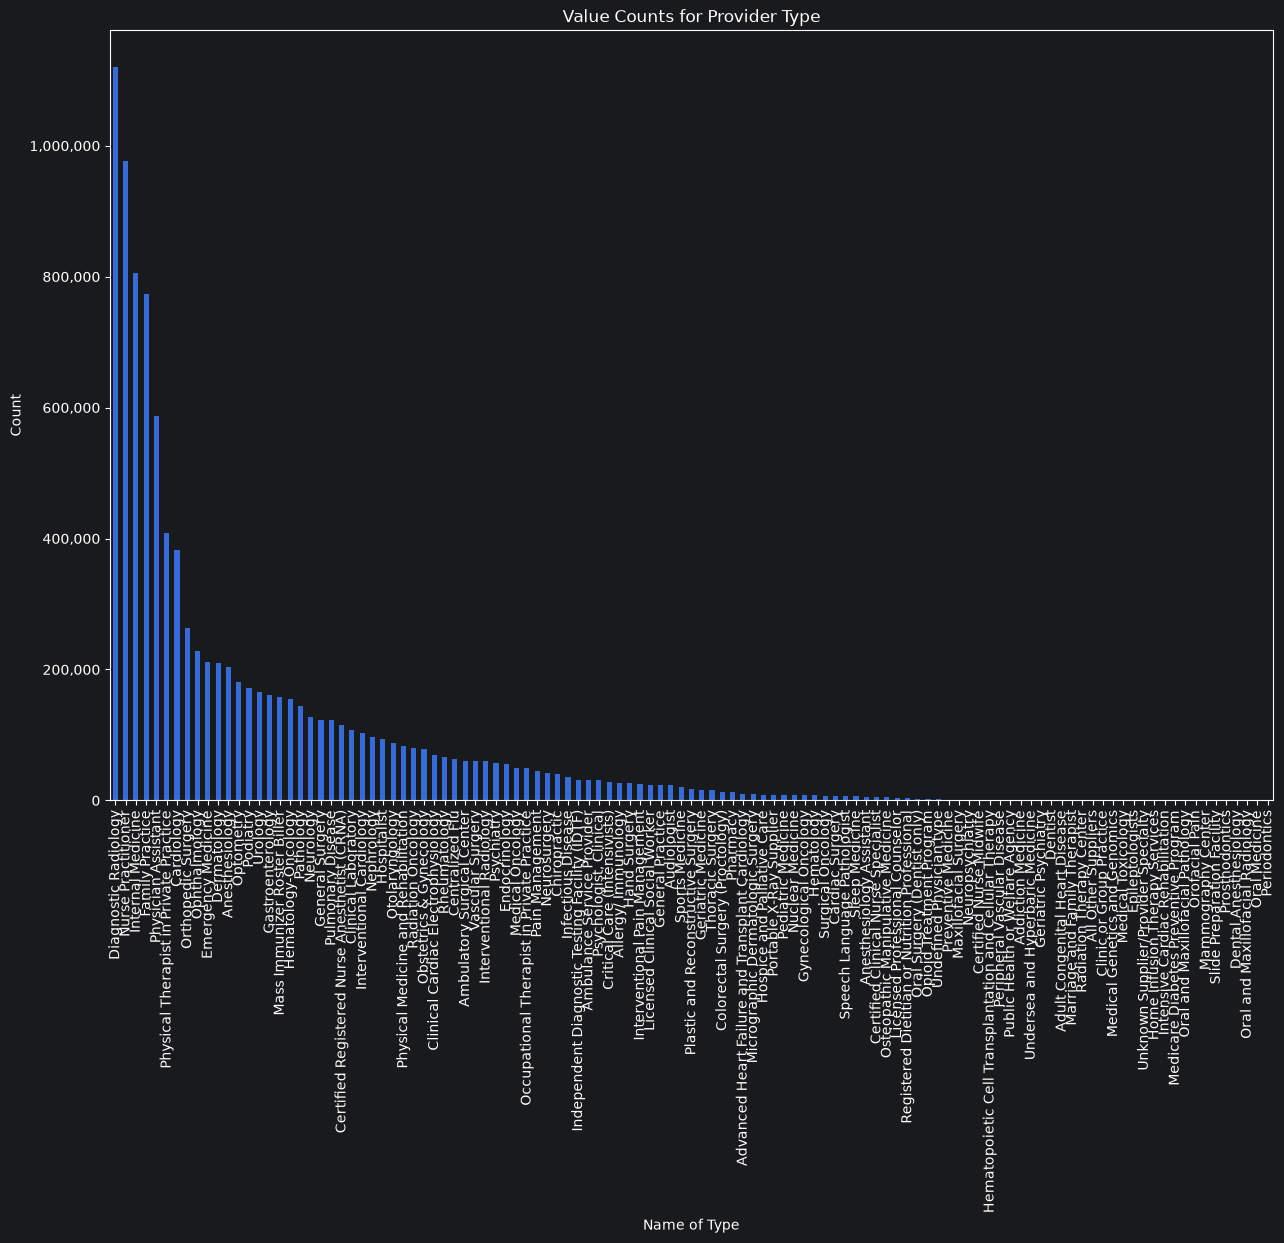

In [83]:
main_type_counts = main_data['Rndrng_Prvdr_Type'].value_counts()
fig, ax = plt.subplots(figsize=(15,10))
main_type_counts.plot(kind='bar')
ax.set_xticklabels(main_type_counts.index, fontsize=10)
ax.yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))
plt.xlabel('Name of Type')
plt.ylabel('Count')
plt.title('Amount of services per Provider Type')
plt.show()

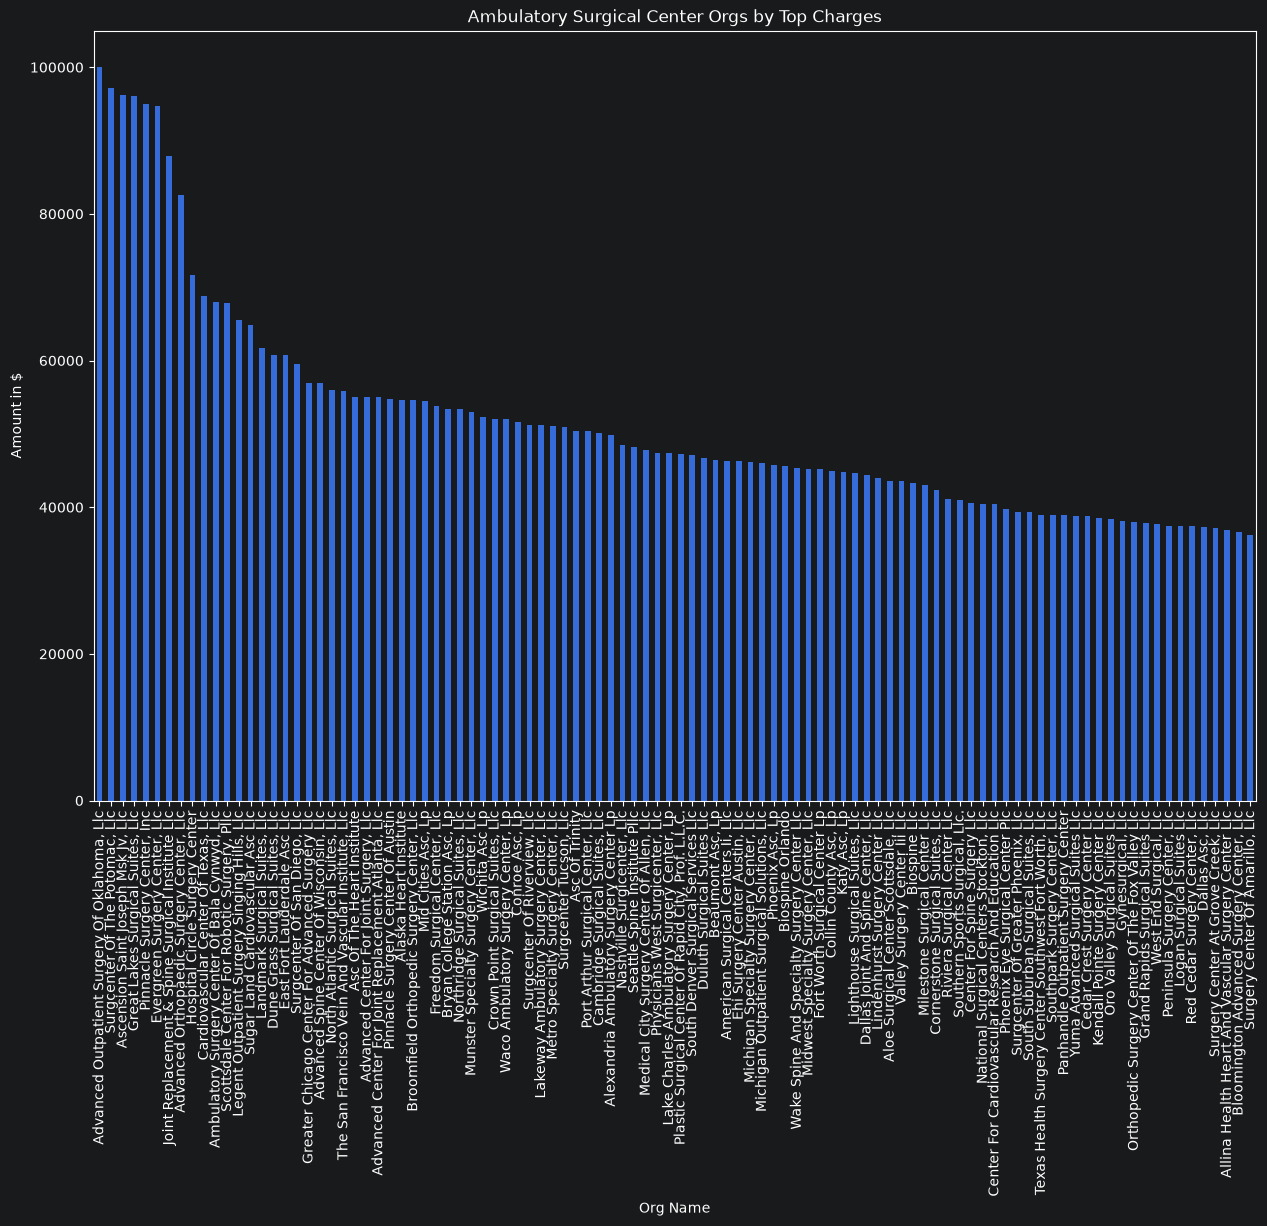

In [84]:
ambulatory = main_data[main_data['Rndrng_Prvdr_Type']=='Ambulatory Surgical Center']
ambulatory_Org_avgCharge = ambulatory.groupby('Rndrng_Prvdr_Last_Org_Name')['Avg_Sbmtd_Chrg'].mean().sort_values(ascending=False).head(100)
fig, ax = plt.subplots(figsize=(15,10))
ambulatory_Org_avgCharge.plot(kind='bar')
ax.set_xticks(range(len(ambulatory_Org_avgCharge.index)))
ax.set_xticklabels(ambulatory_Org_avgCharge.index, rotation=90, fontsize=10)
plt.xlabel('Org Name')
plt.ylabel('Amount in $')
plt.title('Ambulatory Surgical Center Orgs by Top Charges')
plt.show()

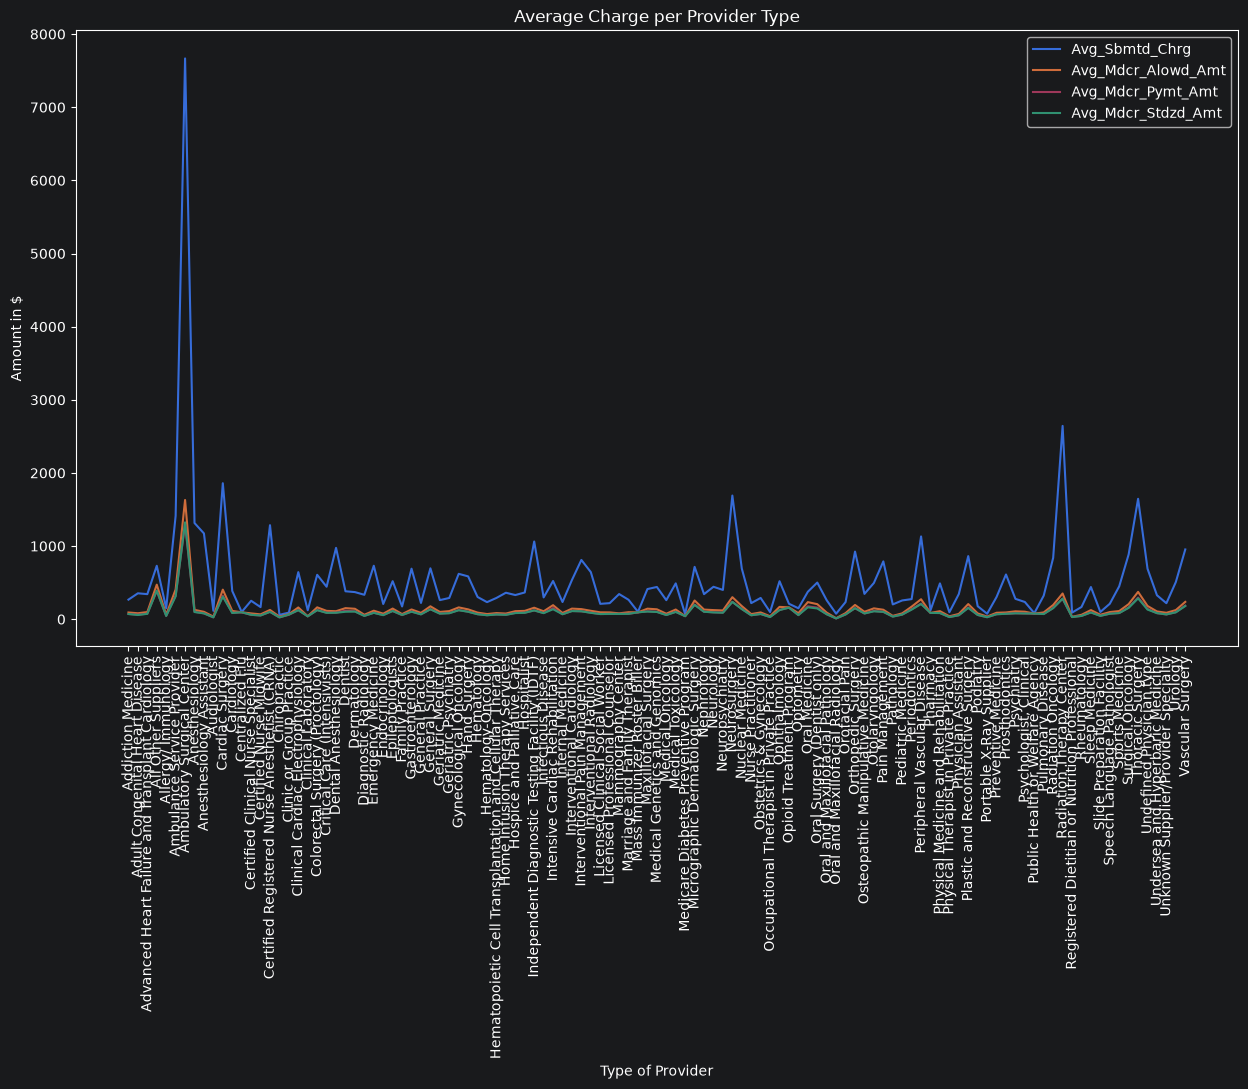

In [91]:
fig, ax = plt.subplots(figsize=(15,8))
main_type_avgCharge = main_data.groupby('Rndrng_Prvdr_Type')['Avg_Sbmtd_Chrg'].mean()
main_type_avgCharge.plot()
main_type_avgMdcrAmt = main_data.groupby('Rndrng_Prvdr_Type')['Avg_Mdcr_Alowd_Amt'].mean()
main_type_avgMdcrAmt.plot()
main_type_avgMdcrPymt = main_data.groupby('Rndrng_Prvdr_Type')['Avg_Mdcr_Pymt_Amt'].mean()
main_type_avgMdcrPymt.plot()
main_type_avgMdcrStdzd = main_data.groupby('Rndrng_Prvdr_Type')['Avg_Mdcr_Stdzd_Amt'].mean()
main_type_avgMdcrStdzd.plot()
ax.set_xticks(range(len(main_type_avgCharge.index)))
ax.set_xticklabels(main_type_avgCharge.index, rotation=90, fontsize=10)
plt.xlabel('Type of Provider')
plt.ylabel('Amount in $')
plt.title('Average Charge per Provider Type')
plt.legend()
plt.show()



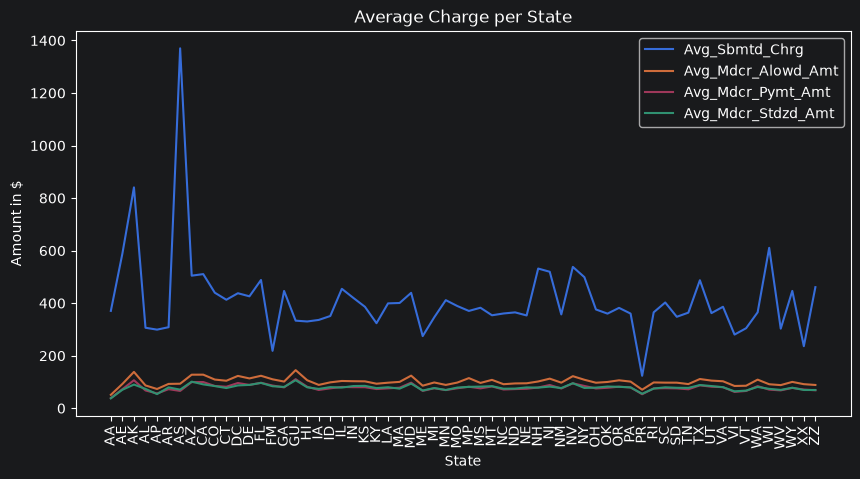

In [87]:
fig, ax = plt.subplots(figsize=(10,5))
main_state_avgCharge = main_data.groupby('Rndrng_Prvdr_State_Abrvtn')['Avg_Sbmtd_Chrg'].mean()
main_state_avgCharge.plot()
main_state_avgMdcrAmt = main_data.groupby('Rndrng_Prvdr_State_Abrvtn')['Avg_Mdcr_Alowd_Amt'].mean()
main_state_avgMdcrAmt.plot()
main_state_avgMdcrPymt = main_data.groupby('Rndrng_Prvdr_State_Abrvtn')['Avg_Mdcr_Pymt_Amt'].mean()
main_state_avgMdcrPymt.plot()
main_state_avgMdcrStdzd = main_data.groupby('Rndrng_Prvdr_State_Abrvtn')['Avg_Mdcr_Stdzd_Amt'].mean()
main_state_avgMdcrStdzd.plot()
ax.set_xticks(range(len(main_state_avgCharge.index)))
ax.set_xticklabels(main_state_avgCharge.index, rotation=90, )
plt.xlabel('State')
plt.ylabel('Amount in $')
plt.title('Average Charge per State')
plt.legend()
plt.show()

In [5]:
data_states = data['Rndrng_Prvdr_State_Abrvtn'].unique()
data_states

<StringArray>
['MD', 'IL', 'OH', 'CO', 'PA', 'OK', 'CA', 'FL', 'TX', 'KY', 'SC', 'NV', 'MO',
 'NY', 'NJ', 'VA', 'LA', 'TN', 'MA', 'OR', 'MI', 'WA', 'ME', 'MN', 'CT', 'GA',
 'NC', 'MS', 'IA', 'ND', 'ID', 'NE', 'AZ', 'AL', 'PR', 'HI', 'RI', 'DC', 'IN',
 'NM', 'AR', 'WV', 'VT', 'NH', 'AE', 'KS', 'DE', 'WI', 'MT', 'WY', 'SD', 'UT',
 'AK', 'GU', 'ZZ', 'VI', 'MP', 'AP', 'XX', 'AA', 'FM', 'AS']
Length: 62, dtype: str

In [ ]:
for state in data_states:
    data_state_temp = data[data['Rndrng_Prvdr_State_Abrvtn']==state]
    data_state_temp.to_csv(f'data_{state}.csv')
    print(f'Exported data_{state}.csv')

In [20]:
import pandas as pd

states = [
    "MD", "IL", "OH", "CO", "PA", "OK", "CA", "FL", "TX", "KY", "SC", "NV", "MO", "NY", "NJ", "VA", "LA", "TN", "MA", "OR","MI", "WA", "ME", "MN", "CT", "GA", "NC", "MS", "IA", "ND","ID", "NE", "AZ", "AL", "PR", "HI", "RI", "DC", "IN", "NM","AR", "WV", "VT", "NH", "AE", "KS", "DE", "WI", "MT", "WY","SD", "UT", "AK", "GU", "ZZ", "VI", "MP", "AP", "XX", "AA","FM", "AS"
]

data = {}

for state in states:
    data[state] = pd.read_csv(f"data/data_states/data_{state}.csv")


Exception ignored in: <function WeakKeyDictionary.__init__.<locals>.remove at 0x000002077E8E1120>
Traceback (most recent call last):
  File "C:\Users\tjwat\AppData\Local\Python\pythoncore-3.12-64\Lib\weakref.py", line 369, in remove
    def remove(k, selfref=ref(self)):

KeyboardInterrupt: 


KeyboardInterrupt: 

In [7]:
data['MD']

,Unnamed: 0,Rndrng_NPI,Rndrng_Prvdr_Last_Org_Name,Rndrng_Prvdr_First_Name,Rndrng_Prvdr_MI,Rndrng_Prvdr_Crdntls,Rndrng_Prvdr_Ent_Cd,Rndrng_Prvdr_St1,Rndrng_Prvdr_St2,Rndrng_Prvdr_City,...,HCPCS_Desc,HCPCS_Drug_Ind,Place_Of_Srvc,Tot_Benes,Tot_Srvcs,Tot_Bene_Day_Srvcs,Avg_Sbmtd_Chrg,Avg_Mdcr_Alowd_Amt,Avg_Mdcr_Pymt_Amt,Avg_Mdcr_Stdzd_Amt
0,0,1003000126,Enkeshafi,Ardalan,NaN,M.D.,I,6410 Rockledge Dr Ste 304,NaN,Bethesda,...,Initial hospital care with straightforward or ...,N,F,36,36.0,36,284.378889,79.063889,60.828889,62.376389
1,1,1003000126,Enkeshafi,Ardalan,NaN,M.D.,I,6410 Rockledge Dr Ste 304,NaN,Bethesda,...,Initial hospital care with straightforward or ...,N,F,150,150.0,150,352.176333,126.340800,95.675600,96.007133
2,2,1003000126,Enkeshafi,Ardalan,NaN,M.D.,I,6410 Rockledge Dr Ste 304,NaN,Bethesda,...,Initial hospital care with moderate level of m...,N,F,63,63.0,63,783.997302,170.360000,134.300476,131.999365
3,3,1003000126,Enkeshafi,Ardalan,NaN,M.D.,I,6410 Rockledge Dr Ste 304,NaN,Bethesda,...,Subsequent hospital care with straightforward ...,N,F,11,16.0,16,122.125000,47.832500,33.350625,33.706250
4,4,1003000126,Enkeshafi,Ardalan,NaN,M.D.,I,6410 Rockledge Dr Ste 304,NaN,Bethesda,...,Subsequent hospital care with moderate levelof...,N,F,37,70.0,70,583.606857,81.428571,62.728714,58.486857
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
228515,9781369,1992996631,Famuyiwa,Funlola,I,NaN,I,111 Brookebury Dr,Apt 1b,Reisterstown,...,Initial hospital care with moderate level of m...,N,F,33,33.0,33,531.000000,169.724545,135.228182,133.741818
228516,9781370,1992996631,Famuyiwa,Funlola,I,NaN,I,111 Brookebury Dr,Apt 1b,Reisterstown,...,Subsequent hospital care with moderate levelof...,N,F,11,12.0,12,242.000000,73.947500,58.919167,60.986667
228517,9781371,1992996631,Famuyiwa,Funlola,I,NaN,I,111 Brookebury Dr,Apt 1b,Reisterstown,...,Subsequent hospital care with moderate levelof...,N,F,18,21.0,21,364.000000,112.498095,90.026667,92.516667
228518,9781372,1992996631,Famuyiwa,Funlola,I,NaN,I,111 Brookebury Dr,Apt 1b,Reisterstown,...,"Critical care, first 30-74 minutes",N,F,93,240.0,240,653.000000,206.499250,164.602667,164.273333


In [10]:
#fig, ax = plt.subplots()
data_MD_Last_Org_Name = data['MD'].groupby('Rndrng_Prvdr_Last_Org_Name')
#ax.plot(data['MD'], data['MD']['Avg_Sbmtd_Chrg'])
#plt.show()
data_MD_Last_Org_Name